In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
plt.style.use('ggplot')
sns.set_palette("Set2")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [4]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    for file in files:
        print("   ", file)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/yasserh
/kaggle/input/datasets/yasserh/walmart-dataset
    Walmart.csv


In [6]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/yasserh/walmart-dataset/Walmart.csv')


In [9]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [10]:
print("="*50)
print("Dataset Shape")
print("="*50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names")
print(df.columns.tolist())

Dataset Shape
Rows    : 6435
Columns : 8

Column Names
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


In [11]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [12]:
df.tail()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


In [15]:
# nissing values
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
Store,0,0.0
Date,0,0.0
Weekly_Sales,0,0.0
Holiday_Flag,0,0.0
Temperature,0,0.0
Fuel_Price,0,0.0
CPI,0,0.0
Unemployment,0,0.0


In [16]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


In [17]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [18]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

In [19]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1


In [1]:
from IPython.display import Markdown, display

display(Markdown("""
# Business Understanding

## Project Title
**AI-Powered Retail Demand Forecasting & Decision Intelligence System**

### Problem Statement
Retail businesses need accurate sales forecasts to optimize inventory, staffing, and promotions. This project develops a machine learning model to forecast weekly sales and generate decision-support recommendations.

### Business Objective
- Forecast weekly sales
- Optimize inventory planning
- Improve workforce allocation
- Support promotional planning

### Target Variable
**Weekly_Sales**

### Machine Learning Task
Supervised Regression

### Expected Outcome
A decision intelligence system that predicts future sales and provides actionable business recommendations.
"""))


# Business Understanding

## Project Title
**AI-Powered Retail Demand Forecasting & Decision Intelligence System**

### Problem Statement
Retail businesses need accurate sales forecasts to optimize inventory, staffing, and promotions. This project develops a machine learning model to forecast weekly sales and generate decision-support recommendations.

### Business Objective
- Forecast weekly sales
- Optimize inventory planning
- Improve workforce allocation
- Support promotional planning

### Target Variable
**Weekly_Sales**

### Machine Learning Task
Supervised Regression

### Expected Outcome
A decision intelligence system that predicts future sales and provides actionable business recommendations.


In [7]:
for col in df.columns:
    print(col)

Store
Date
Weekly_Sales
Holiday_Flag
Temperature
Fuel_Price
CPI
Unemployment


In [8]:
unique = pd.DataFrame({
    'Unique Values': df.nunique()
})

unique

,Unique Values
Store,45
Date,143
Weekly_Sales,6435
Holiday_Flag,2
Temperature,3528
Fuel_Price,892
CPI,2145
Unemployment,349


In [9]:
print("Target Variable : Weekly_Sales")

print()

print(df['Weekly_Sales'].describe())

Target Variable : Weekly_Sales

count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64


In [10]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns")
print(numerical_columns)

print()

print("Categorical Columns")
print(categorical_columns)

Numerical Columns
['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Categorical Columns
['Date']


In [11]:
memory = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage : {memory:.2f} MB")

Memory Usage : 0.71 MB


In [12]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate Rows",
        "Missing Values",
        "Numerical Columns",
        "Categorical Columns"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        len(numerical_columns),
        len(categorical_columns)
    ]
})

summary

,Metric,Value
0,Rows,6435
1,Columns,8
2,Duplicate Rows,0
3,Missing Values,0
4,Numerical Columns,7
5,Categorical Columns,1


In [13]:
# ==========================================================
# Create a Copy of the Dataset
# ==========================================================

data = df.copy()

print("Dataset copied successfully!")

Dataset copied successfully!


In [14]:
# ==========================================================
# Check Missing Values
# ==========================================================

missing_values = data.isnull().sum()

print(missing_values)

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [15]:
# ==========================================================
# Check Duplicate Records
# ==========================================================

print(f"Duplicate Records : {data.duplicated().sum()}")

Duplicate Records : 0


In [16]:
# ==========================================================
# Convert Date Column
# ==========================================================

data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

print(data['Date'].dtype)

datetime64[ns]


In [18]:
# ==========================================================
# Feature Engineering from Date
# ==========================================================

data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Week'] = data['Date'].dt.isocalendar().week.astype(int)
data['Quarter'] = data['Date'].dt.quarter

In [19]:
# ==========================================================
# Sort Dataset
# ==========================================================

data = data.sort_values(['Store','Date'])

data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1


In [20]:
# ==========================================================
# Lag Feature
# ==========================================================

data['Lag_1'] = data.groupby('Store')['Weekly_Sales'].shift(1)

In [21]:
data['Lag_2'] = data.groupby('Store')['Weekly_Sales'].shift(2)

In [22]:
# ==========================================================
# Rolling Mean
# ==========================================================

data['Rolling_Mean_4'] = (
    data.groupby('Store')['Weekly_Sales']
        .transform(lambda x: x.shift(1).rolling(4).mean())
)

In [23]:
# ==========================================================
# Rolling Standard Deviation
# ==========================================================

data['Rolling_STD_4'] = (
    data.groupby('Store')['Weekly_Sales']
        .transform(lambda x: x.shift(1).rolling(4).std())
)

In [24]:
# ==========================================================
# Missing Values After Feature Engineering
# ==========================================================

data.isnull().sum()

Store               0
Date                0
Weekly_Sales        0
Holiday_Flag        0
Temperature         0
Fuel_Price          0
CPI                 0
Unemployment        0
Year                0
Month               0
Week                0
Quarter             0
Lag_1              45
Lag_2              90
Rolling_Mean_4    180
Rolling_STD_4     180
dtype: int64

In [25]:
# ==========================================================
# Remove Missing Rows
# ==========================================================

data = data.dropna().reset_index(drop=True)

print(data.shape)

(6255, 16)


In [26]:
# ==========================================================
# Drop Date Column
# ==========================================================

data = data.drop(columns=['Date'])

In [27]:
# ==========================================================
# Check Data Types
# ==========================================================

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6255 entries, 0 to 6254
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Store           6255 non-null   int64  
 1   Weekly_Sales    6255 non-null   float64
 2   Holiday_Flag    6255 non-null   int64  
 3   Temperature     6255 non-null   float64
 4   Fuel_Price      6255 non-null   float64
 5   CPI             6255 non-null   float64
 6   Unemployment    6255 non-null   float64
 7   Year            6255 non-null   int32  
 8   Month           6255 non-null   int32  
 9   Week            6255 non-null   int64  
 10  Quarter         6255 non-null   int32  
 11  Lag_1           6255 non-null   float64
 12  Lag_2           6255 non-null   float64
 13  Rolling_Mean_4  6255 non-null   float64
 14  Rolling_STD_4   6255 non-null   float64
dtypes: float64(9), int32(3), int64(3)
memory usage: 659.8 KB


In [28]:
# ==========================================================
# Final Prepared Dataset
# ==========================================================

data.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter,Lag_1,Lag_2,Rolling_Mean_4,Rolling_STD_4
0,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1,1409727.59,1611968.17,1.576836e+06,112353.415114
1,1,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,10,1,1554806.68,1409727.59,1.554615e+06,103135.002548
2,1,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,11,1,1439541.59,1554806.68,1.504011e+06,95360.050839
3,1,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,12,1,1472515.79,1439541.59,1.469148e+06,62599.457150
4,1,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,13,2,1404429.92,1472515.79,1.467823e+06,64308.381016


In [29]:
# ==========================================================
# Save Prepared Dataset
# ==========================================================

data.to_csv("prepared_walmart_data.csv", index=False)

print("Prepared dataset saved successfully!")

Prepared dataset saved successfully!


In [31]:
from sklearn.model_selection import train_test_split

In [34]:
# Features
X = data.drop(columns=['Weekly_Sales'])

# Target
y = data['Weekly_Sales']

In [35]:
# ==========================================================
# Time-based Train-Test Split
# ==========================================================

split_index = int(len(data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 5004
Testing Samples  : 1251


In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [38]:
models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

}

In [39]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])


Training Linear Regression...

Training Random Forest...

Training Gradient Boosting...

Training XGBoost...


In [40]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R² Score"
    ]

)

results_df.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
2,Gradient Boosting,42046.646578,61634.439123,0.975155
3,XGBoost,42787.265205,67311.916026,0.970367
1,Random Forest,47667.601855,69341.924150,0.968552
0,Linear Regression,60445.749721,97957.532968,0.937241


In [41]:
best_model = RandomForestRegressor(

    n_estimators=300,

    random_state=42

)

best_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [42]:
predictions = best_model.predict(X_test)

In [43]:
print("MAE :", mean_absolute_error(y_test, predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, predictions)))

print("R² Score :", r2_score(y_test, predictions))

MAE : 47783.007522941574
RMSE : 69337.62179008021
R² Score : 0.9685560948719039


In [44]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
12,Rolling_Mean_4,0.742785
10,Lag_1,0.196135
8,Week,0.032838
13,Rolling_STD_4,0.008604
11,Lag_2,0.005668
2,Temperature,0.002699
4,CPI,0.002302
1,Holiday_Flag,0.002036
5,Unemployment,0.001826
3,Fuel_Price,0.001737


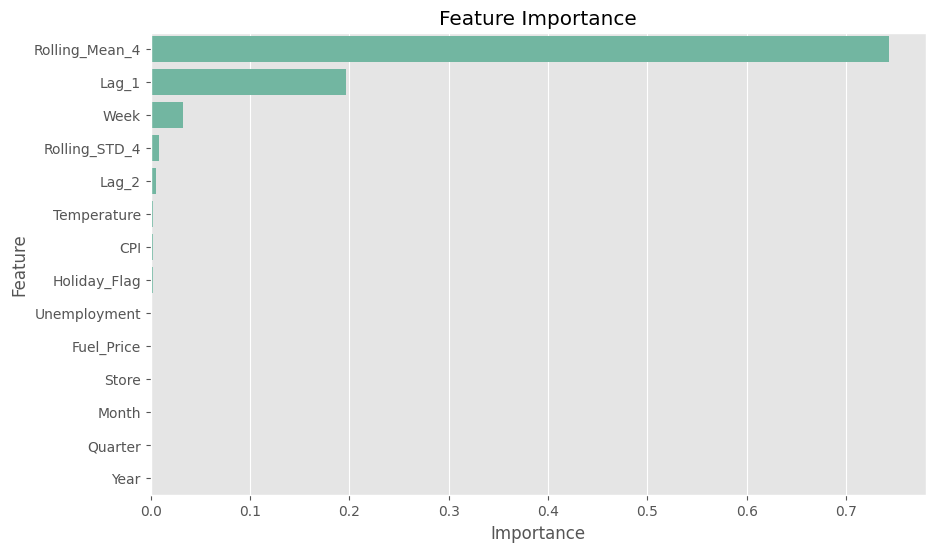

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

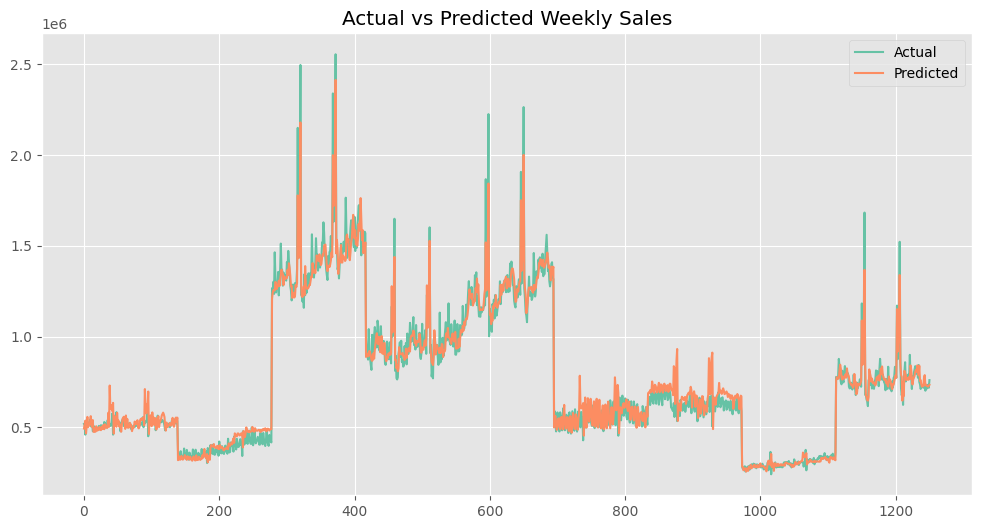

In [46]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Weekly Sales")

plt.show()